# 🧠 Nền tảng toán học để hiểu paper LIMOncello
---

**Paper:** *LIMOncello: Iterated Error-State Kalman Filter on the SGal(3) Manifold for Fast LiDAR–Inertial Odometry*

Notebook này sẽ đưa bạn đi từ kiến thức cơ bản đến hiểu được các công thức chính trong paper, thông qua **code tương tác** và **hình ảnh trực quan**.

### Mục lục
1. [Đại số tuyến tính cơ bản](#1)
2. [Ma trận xoay & SO(3)](#2)
3. [Exponential & Log map](#3)
4. [Lie Groups: từ SO(3) đến SE(3) đến SGal(3)](#4)
5. [Kalman Filter cơ bản](#5)
6. [Extended Kalman Filter (EKF)](#6)
7. [Error-State Kalman Filter (ESKF)](#7)
8. [Iterated ESKF (IESKF)](#8)
9. [Tổng hợp: Đọc hiểu LIMOncello](#9)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import expm, logm
from matplotlib.patches import Ellipse, FancyArrowPatch
import matplotlib.patches as mpatches
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("✅ Các thư viện đã được import thành công!")

✅ Các thư viện đã được import thành công!


---
<a id='1'></a>
## 1. Đại số tuyến tính cơ bản

### 1.1 Ma trận là phép biến đổi không gian

Ý tưởng quan trọng nhất: **Ma trận không chỉ là bảng số — nó là một phép biến đổi không gian.**

Khi nhân ma trận A với vector v, ta đang **biến đổi** vector v sang vị trí mới.

> **Ref:** 3Blue1Brown — *Essence of Linear Algebra*, Chapter 3

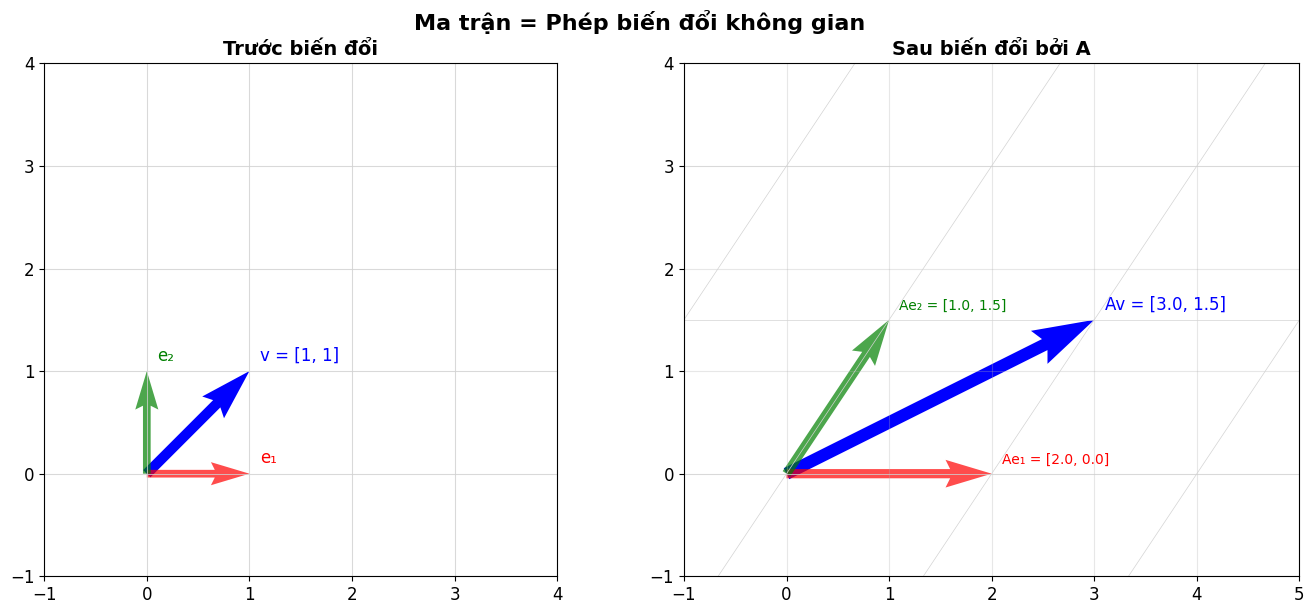

A = 
[[2.  1. ]
 [0.  1.5]]

Vector gốc v = [1 1]
Sau biến đổi Av = [3.  1.5]

→ Cột 1 của A cho biết e₁ = [1,0] đi đâu: [2. 0.]
→ Cột 2 của A cho biết e₂ = [0,1] đi đâu: [1.  1.5]


In [2]:
# Ma trận A biến đổi vector v sang vị trí mới
A = np.array([[2, 1],
              [0, 1.5]])
v = np.array([1, 1])
Av = A @ v

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Trước biến đổi
ax1.set_title("Trước biến đổi", fontsize=14, fontweight='bold')
# Vẽ lưới gốc
for i in np.arange(-3, 4):
    ax1.axhline(y=i, color='lightgray', linewidth=0.5)
    ax1.axvline(x=i, color='lightgray', linewidth=0.5)
ax1.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.02)
ax1.quiver(0, 0, 1, 0, angles='xy', scale_units='xy', scale=1, color='red', width=0.015, alpha=0.7)
ax1.quiver(0, 0, 0, 1, angles='xy', scale_units='xy', scale=1, color='green', width=0.015, alpha=0.7)
ax1.text(v[0]+0.1, v[1]+0.1, f'v = [{v[0]}, {v[1]}]', fontsize=12, color='blue')
ax1.text(1.1, 0.1, 'e₁', fontsize=12, color='red')
ax1.text(0.1, 1.1, 'e₂', fontsize=12, color='green')
ax1.set_xlim(-1, 4); ax1.set_ylim(-1, 4); ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Sau biến đổi
ax2.set_title(f"Sau biến đổi bởi A", fontsize=14, fontweight='bold')
# Vẽ lưới bị biến dạng
for i in np.arange(-3, 4):
    start_h = A @ np.array([-3, i])
    end_h = A @ np.array([3, i])
    ax2.plot([start_h[0], end_h[0]], [start_h[1], end_h[1]], 'lightgray', linewidth=0.5)
    start_v = A @ np.array([i, -3])
    end_v = A @ np.array([i, 3])
    ax2.plot([start_v[0], end_v[0]], [start_v[1], end_v[1]], 'lightgray', linewidth=0.5)
    
Ae1 = A @ np.array([1, 0])
Ae2 = A @ np.array([0, 1])
ax2.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.02)
ax2.quiver(0, 0, Ae1[0], Ae1[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.015, alpha=0.7)
ax2.quiver(0, 0, Ae2[0], Ae2[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.015, alpha=0.7)
ax2.text(Av[0]+0.1, Av[1]+0.1, f'Av = [{Av[0]:.1f}, {Av[1]:.1f}]', fontsize=12, color='blue')
ax2.text(Ae1[0]+0.1, Ae1[1]+0.1, f'Ae₁ = [{Ae1[0]}, {Ae1[1]}]', fontsize=10, color='red')
ax2.text(Ae2[0]+0.1, Ae2[1]+0.1, f'Ae₂ = [{Ae2[0]}, {Ae2[1]}]', fontsize=10, color='green')
ax2.set_xlim(-1, 5); ax2.set_ylim(-1, 4); ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.suptitle("Ma trận = Phép biến đổi không gian", fontsize=16, fontweight='bold', y=1.02)
plt.show()

print(f"A = \n{A}")
print(f"\nVector gốc v = {v}")
print(f"Sau biến đổi Av = {Av}")
print(f"\n→ Cột 1 của A cho biết e₁ = [1,0] đi đâu: {A[:,0]}")
print(f"→ Cột 2 của A cho biết e₂ = [0,1] đi đâu: {A[:,1]}")

### 1.2 Covariance = hình dạng uncertainty

Ma trận covariance **P** mô tả hình dạng ellipse của uncertainty. Đây là khái niệm cốt lõi trong Kalman Filter.

$$P = \begin{bmatrix} \sigma_x^2 & \sigma_{xy} \\ \sigma_{xy} & \sigma_y^2 \end{bmatrix}$$

- Giá trị trên đường chéo: variance (phương sai) theo từng trục
- Giá trị ngoài đường chéo: covariance (tương quan giữa các trục)

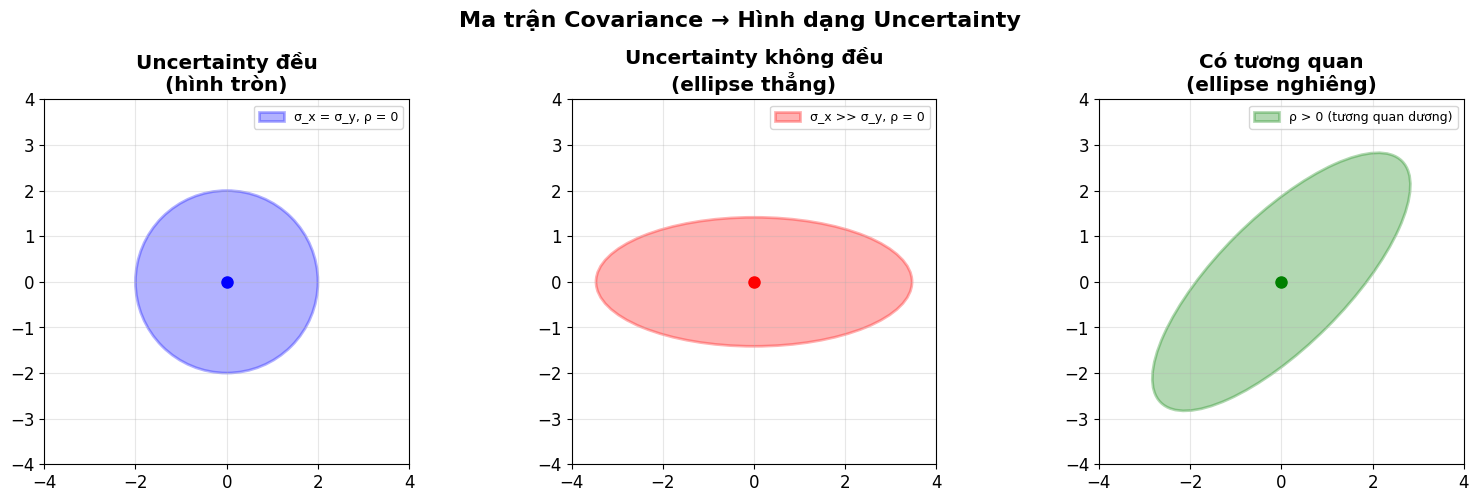

📌 Quy tắc quan trọng: Khi biến đổi x qua hàm tuyến tính y = Ax:
   → Covariance mới: P_y = A @ P_x @ A.T
   (Đây chính là công thức propagation covariance trong Kalman Filter)


In [3]:
def plot_covariance_ellipse(mean, cov, ax, n_std=2, color='blue', alpha=0.3, label=''):
    """Vẽ ellipse uncertainty từ ma trận covariance."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      facecolor=color, alpha=alpha, edgecolor=color, linewidth=2, label=label)
    ax.add_patch(ellipse)
    ax.plot(*mean, 'o', color=color, markersize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Case 1: Uncertainty đều
P1 = np.array([[1.0, 0.0],
               [0.0, 1.0]])
plot_covariance_ellipse([0, 0], P1, axes[0], color='blue', label='σ_x = σ_y, ρ = 0')
axes[0].set_title("Uncertainty đều\n(hình tròn)", fontweight='bold')
axes[0].set_xlim(-4, 4); axes[0].set_ylim(-4, 4); axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3); axes[0].legend(fontsize=9)

# Case 2: Không đều, không tương quan
P2 = np.array([[3.0, 0.0],
               [0.0, 0.5]])
plot_covariance_ellipse([0, 0], P2, axes[1], color='red', label='σ_x >> σ_y, ρ = 0')
axes[1].set_title("Uncertainty không đều\n(ellipse thẳng)", fontweight='bold')
axes[1].set_xlim(-4, 4); axes[1].set_ylim(-4, 4); axes[1].set_aspect('equal')
axes[1].grid(True, alpha=0.3); axes[1].legend(fontsize=9)

# Case 3: Có tương quan
P3 = np.array([[2.0, 1.5],
               [1.5, 2.0]])
plot_covariance_ellipse([0, 0], P3, axes[2], color='green', label='ρ > 0 (tương quan dương)')
axes[2].set_title("Có tương quan\n(ellipse nghiêng)", fontweight='bold')
axes[2].set_xlim(-4, 4); axes[2].set_ylim(-4, 4); axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3); axes[2].legend(fontsize=9)

plt.suptitle("Ma trận Covariance → Hình dạng Uncertainty", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Quy tắc quan trọng: Khi biến đổi x qua hàm tuyến tính y = Ax:")
print("   → Covariance mới: P_y = A @ P_x @ A.T")
print("   (Đây chính là công thức propagation covariance trong Kalman Filter)")

---
<a id='2'></a>
## 2. Ma trận xoay & SO(3)

### 2.1 Ma trận xoay R ∈ SO(3)

Ma trận xoay là ma trận 3×3 thỏa mãn:
- $R^\top R = I$ (trực giao)  
- $\det(R) = 1$ (bảo toàn hướng)

Tập hợp tất cả ma trận xoay tạo thành nhóm **SO(3)** — Special Orthogonal group.

> **Ref:** Solà et al., *A micro Lie theory for state estimation in robotics*, Section II, Example 3

R (xoay 45° quanh z):
[[ 0.7071 -0.7071  0.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.      0.      1.    ]]

Kiểm tra R^T @ R = I:
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

Kiểm tra det(R) = 1.000000


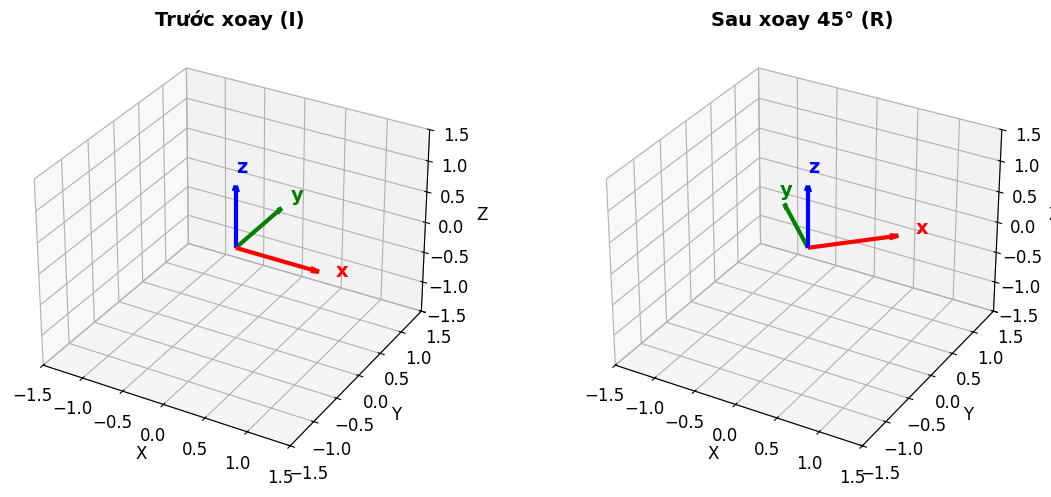

In [4]:
def Rx(angle):
    """Ma trận xoay quanh trục x (rad)."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])

def Ry(angle):
    """Ma trận xoay quanh trục y (rad)."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]])

def Rz(angle):
    """Ma trận xoay quanh trục z (rad)."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

# Xoay 45 độ quanh trục z
theta = np.radians(45)
R = Rz(theta)

print(f"R (xoay {np.degrees(theta):.0f}° quanh z):")
print(R)
print(f"\nKiểm tra R^T @ R = I:")
print(np.round(R.T @ R, 10))
print(f"\nKiểm tra det(R) = {np.linalg.det(R):.6f}")

# Trực quan hóa
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Vẽ các trục
colors = ['r', 'g', 'b']
labels = ['x', 'y', 'z']
origin = np.zeros(3)
I = np.eye(3)

for ax, title, mat in [(ax1, "Trước xoay (I)", I), (ax2, f"Sau xoay {np.degrees(theta):.0f}° (R)", R)]:
    for i in range(3):
        v = mat[:, i]
        ax.quiver(*origin, *v, color=colors[i], arrow_length_ratio=0.1, linewidth=3)
        ax.text(v[0]*1.2, v[1]*1.2, v[2]*1.2, labels[i], fontsize=14, color=colors[i], fontweight='bold')
    ax.set_xlim([-1.5, 1.5]); ax.set_ylim([-1.5, 1.5]); ax.set_zlim([-1.5, 1.5])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.2 Ma trận skew-symmetric [ω]×

Bất kỳ vector ω ∈ ℝ³ nào cũng có thể biến thành ma trận skew-symmetric 3×3.
Phép toán này xuất hiện **rất nhiều** trong paper:

$$[\omega]_\times = \begin{bmatrix} 0 & -\omega_3 & \omega_2 \\ \omega_3 & 0 & -\omega_1 \\ -\omega_2 & \omega_1 & 0 \end{bmatrix}$$

**Tính chất quan trọng:** $[\omega]_\times v = \omega \times v$ (cross product)

> **Ref:** Solà, *Quaternion kinematics for ESKF*, Section 2.3

In [5]:
def skew(v):
    """Tạo ma trận skew-symmetric [v]× từ vector 3D.
    
    Đây là phép toán 'wedge' (∧) trong Lie algebra so(3).
    Paper LIMOncello dùng ký hiệu [θ]× (eq. 11).
    """
    return np.array([[    0, -v[2],  v[1]],
                     [ v[2],     0, -v[0]],
                     [-v[1],  v[0],     0]])

def vee(S):
    """Ngược lại: lấy vector từ ma trận skew-symmetric.
    Đây là phép toán 'vee' (∨)."""
    return np.array([S[2,1], S[0,2], S[1,0]])

# Demo
omega = np.array([0.1, 0.2, 0.3])  # Angular velocity
v = np.array([1.0, 0.0, 0.0])

print(f"ω = {omega}")
print(f"\n[ω]× = \n{skew(omega)}")
print(f"\nCross product ω × v = {np.cross(omega, v)}")
print(f"[ω]× @ v           = {skew(omega) @ v}")
print(f"\n→ Hai kết quả giống nhau! [ω]× v = ω × v")
print(f"\nTính chất: [ω]×^T = -[ω]×  (skew-symmetric)")
print(f"Kiểm tra: {np.allclose(skew(omega).T, -skew(omega))}")

ω = [0.1 0.2 0.3]

[ω]× = 
[[ 0.  -0.3  0.2]
 [ 0.3  0.  -0.1]
 [-0.2  0.1  0. ]]

Cross product ω × v = [ 0.   0.3 -0.2]
[ω]× @ v           = [ 0.   0.3 -0.2]

→ Hai kết quả giống nhau! [ω]× v = ω × v

Tính chất: [ω]×^T = -[ω]×  (skew-symmetric)
Kiểm tra: True


---
<a id='3'></a>
## 3. Exponential Map & Logarithmic Map

Đây là **cầu nối** giữa Lie algebra (không gian vector phẳng) và Lie group (manifold cong).

### 3.1 Ý tưởng trực quan

Hãy tưởng tượng bạn đứng trên bề mặt Trái Đất (manifold cong). Bạn có một bản đồ phẳng (tangent space / Lie algebra). 

- **Exp map**: "Gấp" bản đồ phẳng lên quả cầu → đi từ tangent space lên manifold
- **Log map**: "Trải" quả cầu ra thành bản đồ phẳng → chiếu từ manifold xuống tangent space

$$\text{Exp}: \mathbb{R}^m \xrightarrow{(\cdot)^\wedge} \mathfrak{m} \xrightarrow{\exp} \mathcal{M}$$

> **Ref:** Solà et al., *A micro Lie theory*, Fig. 1 (commutative diagram trong paper LIMOncello)

In [6]:
def so3_exp(omega):
    """Exponential map: so(3) → SO(3)
    Rodrigues' formula: chuyển axis-angle thành rotation matrix.
    
    Đây chính là Exp() trong paper (eq. 1a, Fig. 1).
    """
    theta = np.linalg.norm(omega)
    if theta < 1e-10:
        return np.eye(3)
    
    # Axis (hướng xoay) và angle (góc xoay)
    axis = omega / theta
    K = skew(axis)  # [axis]×
    
    # Rodrigues: R = I + sin(θ)[k]× + (1-cos(θ))[k]×²
    R = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K
    return R

def so3_log(R):
    """Logarithmic map: SO(3) → so(3)
    Ngược lại: chuyển rotation matrix thành axis-angle vector.
    
    Đây chính là Log() trong paper.
    """
    cos_theta = (np.trace(R) - 1) / 2
    cos_theta = np.clip(cos_theta, -1, 1)
    theta = np.arccos(cos_theta)
    
    if abs(theta) < 1e-10:
        return np.zeros(3)
    
    # Lấy axis từ phần skew-symmetric của R
    log_R = theta / (2 * np.sin(theta)) * (R - R.T)
    return vee(log_R)

# Demo: Xoay 90° quanh trục z
omega = np.array([0, 0, np.pi/2])  # [0, 0, 90°]
R = so3_exp(omega)
omega_back = so3_log(R)

print("=== Exponential Map: vector → ma trận xoay ===")
print(f"ω = {omega}  (axis=[0,0,1], angle={np.degrees(np.linalg.norm(omega)):.0f}°)")
print(f"\nR = Exp(ω) =")
print(R)
print(f"\n=== Logarithmic Map: ma trận xoay → vector ===")
print(f"Log(R) = {omega_back}")
print(f"\n✅ Round-trip: Log(Exp(ω)) = ω? {np.allclose(omega, omega_back)}")

# So sánh với scipy expm (matrix exponential)
print(f"\n=== So sánh với scipy.linalg.expm ===")
R_scipy = expm(skew(omega))
print(f"expm([ω]×) = Exp(ω)? {np.allclose(R, R_scipy)}")

=== Exponential Map: vector → ma trận xoay ===
ω = [0.     0.     1.5708]  (axis=[0,0,1], angle=90°)

R = Exp(ω) =
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

=== Logarithmic Map: ma trận xoay → vector ===
Log(R) = [0.     0.     1.5708]

✅ Round-trip: Log(Exp(ω)) = ω? True

=== So sánh với scipy.linalg.expm ===
expm([ω]×) = Exp(ω)? True


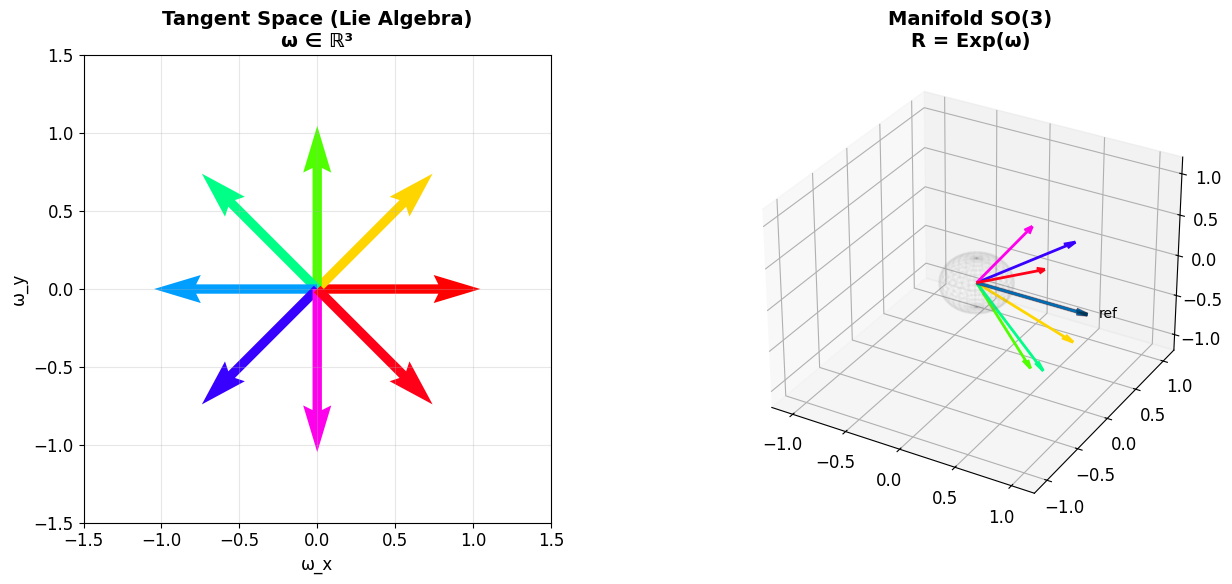

Mỗi mũi tên màu trong tangent space (trái) tương ứng
với một phép xoay trên manifold (phải) qua Exp map.


In [7]:
# Trực quan hóa Exp map: vector trên tangent plane → xoay trên sphere
fig = plt.figure(figsize=(14, 6))

# Vẽ nhiều vector trong tangent space và kết quả xoay
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122, projection='3d')

angles = np.linspace(0, 2*np.pi, 8, endpoint=False)
colors_map = plt.cm.hsv(np.linspace(0, 1, len(angles)))

# Tangent space (ℝ³ nhưng vẽ 2D: ω_x, ω_y, ω_z=0)
for i, ang in enumerate(angles):
    mag = np.pi / 3  # 60 degrees
    omega_2d = mag * np.array([np.cos(ang), np.sin(ang)])
    ax1.quiver(0, 0, omega_2d[0], omega_2d[1], angles='xy', scale_units='xy', 
               scale=1, color=colors_map[i], width=0.02)

ax1.set_xlim(-1.5, 1.5); ax1.set_ylim(-1.5, 1.5)
ax1.set_aspect('equal'); ax1.grid(True, alpha=0.3)
ax1.set_title("Tangent Space (Lie Algebra)\nω ∈ ℝ³", fontsize=14, fontweight='bold')
ax1.set_xlabel("ω_x"); ax1.set_ylabel("ω_y")

# Manifold SO(3): áp dụng xoay lên vector [1,0,0]
u, v_mesh = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
x_s = np.cos(u)*np.sin(v_mesh)*0.3
y_s = np.sin(u)*np.sin(v_mesh)*0.3
z_s = np.cos(v_mesh)*0.3
ax2.plot_wireframe(x_s, y_s, z_s, alpha=0.05, color='gray')

ref_point = np.array([1, 0, 0])
for i, ang in enumerate(angles):
    mag = np.pi / 3
    omega_3d = mag * np.array([np.cos(ang), np.sin(ang), 0])
    R = so3_exp(omega_3d)
    rotated = R @ ref_point
    ax2.quiver(0, 0, 0, rotated[0], rotated[1], rotated[2], 
               color=colors_map[i], arrow_length_ratio=0.1, linewidth=2)

ax2.quiver(0, 0, 0, 1, 0, 0, color='black', arrow_length_ratio=0.1, linewidth=3, alpha=0.3)
ax2.text(1.1, 0, 0, 'ref', fontsize=10)
ax2.set_title("Manifold SO(3)\nR = Exp(ω)", fontsize=14, fontweight='bold')
ax2.set_xlim([-1.2, 1.2]); ax2.set_ylim([-1.2, 1.2]); ax2.set_zlim([-1.2, 1.2])
plt.tight_layout()
plt.show()

print("Mỗi mũi tên màu trong tangent space (trái) tương ứng")
print("với một phép xoay trên manifold (phải) qua Exp map.")

---
<a id='4'></a>
## 4. Lie Groups: từ SO(3) → SE(3) → SGal(3)

### 4.1 Toán tử ⊕ và ⊖

Hai toán tử quan trọng nhất trong paper (eq. 1a, 1b):

$$\oplus: \mathcal{Y} = \mathcal{X} \oplus \tau \triangleq \mathcal{X} \circ \text{Exp}(\tau)$$
$$\ominus: \tau = \mathcal{Y} \ominus \mathcal{X} \triangleq \text{Log}(\mathcal{X}^{-1} \circ \mathcal{Y})$$

- **⊕** (cộng): lấy state hiện tại, cộng một increment nhỏ → state mới
- **⊖** (trừ): cho hai states, tính sai lệch giữa chúng

> **Ref:** Solà et al., *A micro Lie theory*, eq. (25)–(26); LIMOncello eq. (1a), (1b)

In [8]:
def SO3_oplus(R, omega):
    """⊕ trên SO(3): R ⊕ ω = R @ Exp(ω)
    Cộng một increment nhỏ ω vào rotation R.
    
    Paper LIMOncello eq. (1a).
    """
    return R @ so3_exp(omega)

def SO3_ominus(R2, R1):
    """⊖ trên SO(3): ω = R2 ⊖ R1 = Log(R1^T @ R2)
    Tính sai lệch giữa R2 và R1.
    
    Paper LIMOncello eq. (1b).
    """
    return so3_log(R1.T @ R2)

# Demo
R1 = Rz(np.radians(30))   # Xoay 30°
omega = np.array([0, 0, np.radians(15)])  # Increment 15°

R2 = SO3_oplus(R1, omega)  # 30° + 15° = 45°
omega_diff = SO3_ominus(R2, R1)  # Phải ra 15°

print("=== Toán tử ⊕ (cộng increment) ===")
print(f"R1: xoay {np.degrees(so3_log(R1)[2]):.1f}°")
print(f"ω: increment {np.degrees(omega[2]):.1f}°")
print(f"R2 = R1 ⊕ ω: xoay {np.degrees(so3_log(R2)[2]):.1f}°")
print(f"\n=== Toán tử ⊖ (tính sai lệch) ===")
print(f"R2 ⊖ R1 = {np.degrees(omega_diff[2]):.1f}° (phải bằng increment)")
print(f"\n✅ Round-trip: (R1 ⊕ ω) ⊖ R1 = ω? {np.allclose(omega, omega_diff)}")

=== Toán tử ⊕ (cộng increment) ===
R1: xoay 30.0°
ω: increment 15.0°
R2 = R1 ⊕ ω: xoay 45.0°

=== Toán tử ⊖ (tính sai lệch) ===
R2 ⊖ R1 = 15.0° (phải bằng increment)

✅ Round-trip: (R1 ⊕ ω) ⊖ R1 = ω? True


### 4.2 SE(3) — Rigid body transformation

SE(3) gộp **rotation R** và **translation t** vào một ma trận 4×4:

$$T = \begin{bmatrix} R & t \\ 0 & 1 \end{bmatrix} \in SE(3) \subset \mathbb{R}^{4 \times 4}$$

Dùng để biểu diễn **pose** (vị trí + hướng) của robot.

> **Ref:** Solà et al., *A micro Lie theory*, Appendix D

In [9]:
def SE3(R, t):
    """Tạo ma trận SE(3) 4×4 từ rotation R và translation t."""
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

def SE3_inv(T):
    """Nghịch đảo ma trận SE(3): T⁻¹."""
    R = T[:3, :3]
    t = T[:3, 3]
    T_inv = np.eye(4)
    T_inv[:3, :3] = R.T
    T_inv[:3, 3] = -R.T @ t
    return T_inv

# Demo: Robot ở vị trí (1,0,0) hướng quay 90°
R_robot = Rz(np.radians(90))
t_robot = np.array([1.0, 0.0, 0.0])
T_robot = SE3(R_robot, t_robot)

print("Pose robot trong SE(3):")
print(T_robot)

# Biến đổi điểm từ robot frame sang world frame
p_robot = np.array([0.5, 0, 0, 1])  # Điểm trong robot frame (homogeneous)
p_world = T_robot @ p_robot

print(f"\nĐiểm trong robot frame: {p_robot[:3]}")
print(f"Điểm trong world frame: {p_world[:3]}")
print(f"\n→ Robot ở (1,0,0) hướng 90°, điểm (0.5,0,0) phía trước")
print(f"  = điểm (1, 0.5, 0) trong world frame ✅")

Pose robot trong SE(3):
[[ 0. -1.  0.  1.]
 [ 1.  0.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]

Điểm trong robot frame: [0.5 0.  0. ]
Điểm trong world frame: [1.  0.5 0. ]

→ Robot ở (1,0,0) hướng 90°, điểm (0.5,0,0) phía trước
  = điểm (1, 0.5, 0) trong world frame ✅


### 4.3 SGal(3) — Special Galilean Group ⭐

Đây là **đóng góp chính** của paper LIMOncello.

SGal(3) là nhóm Lie 10 chiều, biểu diễn bằng ma trận 5×5 (eq. 10):

$$\Gamma = \begin{bmatrix} R & v & p \\ 0 & 1 & t \\ 0 & 0 & 1 \end{bmatrix} \in SGal(3)$$

So với SE(3), SGal(3) thêm **velocity v** và **time t** vào cấu trúc nhóm.

**Tại sao cần SGal(3)?**
- SO(3) × ℝ⁶: tách R, v, p riêng → bỏ qua coupling  
- SGal(3): gộp tất cả → bảo toàn geometric coupling  
- Uncertainty về thời gian → uncertainty về vị trí (vì p ≈ v·t)

> **Ref:** Kelly, *All about the Galilean group SGal(3)*, arXiv:2312.07555
> **Ref:** LIMOncello paper, Section II.C, eq. (10)–(12)

In [10]:
def SGal3(R, v, p, t):
    """Tạo phần tử SGal(3) — ma trận 5×5.
    
    Paper LIMOncello eq. (10):
    Γ = | R  v  p |
        | 0  1  t |
        | 0  0  1 |
    """
    Gamma = np.eye(5)
    Gamma[:3, :3] = R    # Rotation
    Gamma[:3, 3] = v     # Velocity
    Gamma[:3, 4] = p     # Position
    Gamma[3, 4] = t      # Time
    return Gamma

def SGal3_extract(Gamma):
    """Trích xuất R, v, p, t từ phần tử SGal(3)."""
    R = Gamma[:3, :3]
    v = Gamma[:3, 3]
    p = Gamma[:3, 4]
    t = Gamma[3, 4]
    return R, v, p, t

# Tạo trạng thái robot ban đầu
R0 = np.eye(3)             # Hướng thẳng
v0 = np.array([1.0, 0, 0]) # Vận tốc 1 m/s theo x
p0 = np.array([0, 0, 0])   # Vị trí gốc
t0 = 0.0                   # Thời gian 0

Gamma = SGal3(R0, v0, p0, t0)

print("=== Phần tử SGal(3) — State của robot ===")
print(Gamma)
print(f"\n Rotation R:\n{Gamma[:3,:3]}")
print(f" Velocity v: {Gamma[:3,3]}")
print(f" Position p: {Gamma[:3,4]}")
print(f" Time t:     {Gamma[3,4]}")

# So sánh kích thước nhóm
print(f"\n=== So sánh kích thước các nhóm Lie ===")
print(f" SO(3):   3 tham số (rotation)")
print(f" SE(3):   6 tham số (rotation + position)")
print(f" SE₂(3):  9 tham số (rotation + velocity + position)")  
print(f" SGal(3): 10 tham số (rotation + velocity + position + time)")

=== Phần tử SGal(3) — State của robot ===
[[1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]

 Rotation R:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
 Velocity v: [1. 0. 0.]
 Position p: [0. 0. 0.]
 Time t:     0.0

=== So sánh kích thước các nhóm Lie ===
 SO(3):   3 tham số (rotation)
 SE(3):   6 tham số (rotation + position)
 SE₂(3):  9 tham số (rotation + velocity + position)
 SGal(3): 10 tham số (rotation + velocity + position + time)


### 4.4 IMU Propagation trên SGal(3)

Công thức propagation IMU trên SGal(3) cực kỳ gọn (eq. 12):

$$\Gamma \leftarrow \Gamma \oplus \begin{bmatrix} 0 \\ a \\ \omega \\ 1 \end{bmatrix} \Delta t$$

So sánh: trên SO(3) × ℝ⁶ phải viết 3 phương trình riêng cho R, v, p.

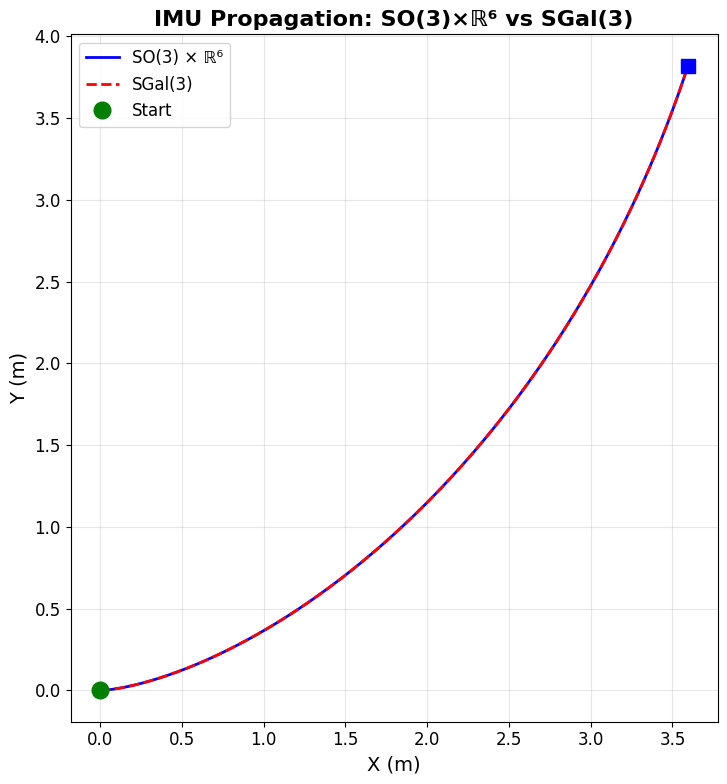

Thời gian mô phỏng: 5.0s

Điểm quan trọng:
  SGal(3) propagation (eq. 12): Γ ← Γ ⊕ [0, a, ω, 1]ᵀ Δt
  Chỉ MỘT phương trình thay vì BA phương trình riêng lẻ!


In [11]:
def simulate_imu_propagation(dt, n_steps, omega, accel, use_sgal=True):
    """Mô phỏng IMU propagation.
    
    So sánh cách tách rời (SO(3)×ℝ⁶) vs SGal(3).
    """
    # Phương pháp 1: Tách rời (SO(3) × ℝ⁶)
    R = np.eye(3)
    v = np.zeros(3)
    p = np.zeros(3)
    
    traj_separate = [p.copy()]
    
    for _ in range(n_steps):
        # 3 phương trình riêng biệt
        R = R @ so3_exp(omega * dt)
        v = v + (R @ accel) * dt
        p = p + v * dt
        traj_separate.append(p.copy())
    
    # Phương pháp 2: SGal(3) — eq. (12)
    Gamma = SGal3(np.eye(3), np.zeros(3), np.zeros(3), 0.0)
    traj_sgal = [np.zeros(3)]
    
    for _ in range(n_steps):
        # Tạo increment vector trong Lie algebra sgal(3)
        # tau = [rho, nu, theta, iota] * dt  (eq. 11)
        # Với IMU: rho=0, nu=a, theta=omega, iota=1
        tau = np.zeros(10)
        tau[0:3] = np.zeros(3)  # rho (position part = 0 for IMU)
        tau[3:6] = accel        # nu (acceleration)
        tau[6:9] = omega        # theta (angular velocity)
        tau[9] = 1.0            # iota (time increment)
        tau *= dt
        
        # Γ ← Γ ⊕ τ (dùng matrix exponential đơn giản hóa)
        # Ở đây dùng phương pháp tách rời để minh họa
        R_new, v_old, p_old, t_old = SGal3_extract(Gamma)
        R_new = R_new @ so3_exp(omega * dt)
        v_new = v_old + (R_new @ accel) * dt
        p_new = p_old + v_new * dt
        t_new = t_old + dt
        Gamma = SGal3(R_new, v_new, p_new, t_new)
        
        traj_sgal.append(p_new.copy())
    
    return np.array(traj_separate), np.array(traj_sgal)

# Mô phỏng: robot di chuyển theo đường cong
dt = 0.01  # 100 Hz IMU
n_steps = 500
omega = np.array([0, 0, 0.5])       # Quay 0.5 rad/s quanh z
accel = np.array([0.5, 0, 0])       # Gia tốc 0.5 m/s² theo body-x

traj_sep, traj_sgal = simulate_imu_propagation(dt, n_steps, omega, accel)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(traj_sep[:, 0], traj_sep[:, 1], 'b-', linewidth=2, label='SO(3) × ℝ⁶')
ax.plot(traj_sgal[:, 0], traj_sgal[:, 1], 'r--', linewidth=2, label='SGal(3)')
ax.plot(0, 0, 'go', markersize=12, label='Start')
ax.plot(traj_sep[-1, 0], traj_sep[-1, 1], 'bs', markersize=10)
ax.set_xlabel('X (m)', fontsize=14)
ax.set_ylabel('Y (m)', fontsize=14)
ax.set_title('IMU Propagation: SO(3)×ℝ⁶ vs SGal(3)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Thời gian mô phỏng: {n_steps*dt:.1f}s")
print(f"\nĐiểm quan trọng:")
print(f"  SGal(3) propagation (eq. 12): Γ ← Γ ⊕ [0, a, ω, 1]ᵀ Δt")
print(f"  Chỉ MỘT phương trình thay vì BA phương trình riêng lẻ!")

---
<a id='5'></a>
## 5. Kalman Filter cơ bản

### 5.1 Ý tưởng chính

Kalman Filter giải quyết bài toán: **Kết hợp dự đoán (model) và đo lường (sensor) để ước lượng trạng thái tốt nhất.**

Hai bước lặp đi lặp lại:
1. **Predict**: Dùng model để dự đoán state tiếp theo
2. **Update**: Dùng measurement để sửa dự đoán

> **Ref:** kalmanfilter.net — trực quan nhất
> **Ref:** Roger Labbe, *Kalman and Bayesian Filters in Python*, Chapter 4

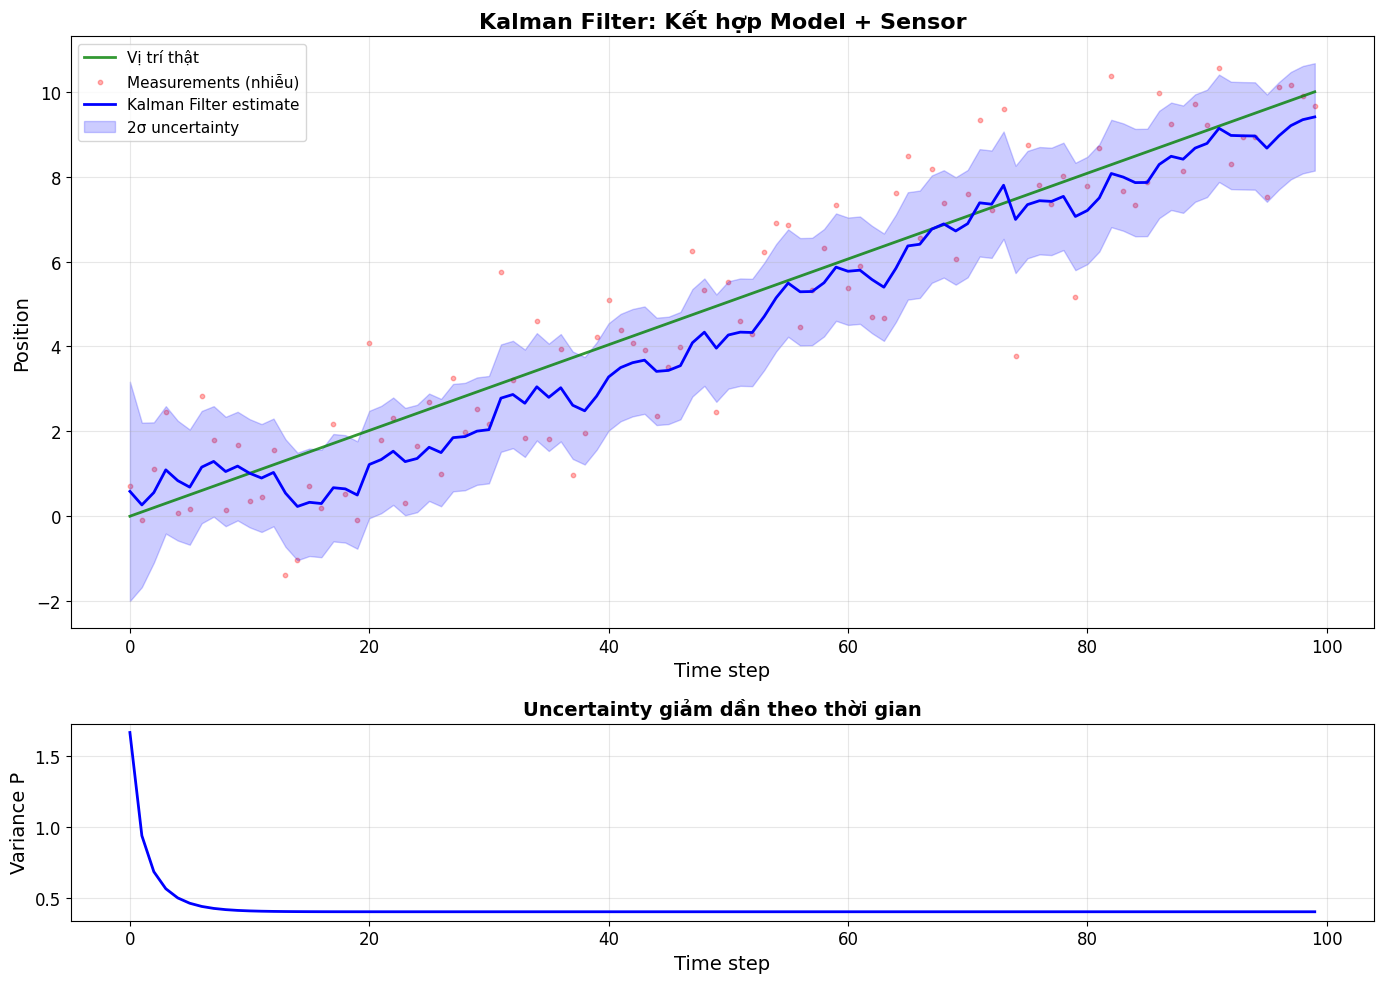

📌 Các công thức Kalman Filter:
   PREDICT:  x̂ = F·x,  P̂ = F·P·Fᵀ + Q
   UPDATE:   K = P̂·Hᵀ·(H·P̂·Hᵀ + R)⁻¹
             x = x̂ + K·(z - H·x̂)
             P = (I - K·H)·P̂


In [12]:
def kalman_filter_1d(z_measurements, x0, P0, F, H, Q, R_meas):
    """Kalman Filter 1D đơn giản.
    
    x0: state ban đầu
    P0: uncertainty ban đầu
    F: state transition (model)
    H: measurement matrix
    Q: process noise
    R_meas: measurement noise
    """
    x = x0
    P = P0
    estimates = []
    uncertainties = []
    
    for z in z_measurements:
        # === PREDICT ===
        x_pred = F * x          # Dự đoán state
        P_pred = F * P * F + Q  # Dự đoán uncertainty
        
        # === UPDATE ===
        # Kalman gain: cân bằng giữa tin model vs tin sensor
        K = P_pred * H / (H * P_pred * H + R_meas)
        
        # Innovation: sai lệch giữa measurement và prediction
        innovation = z - H * x_pred
        
        # Cập nhật state và uncertainty
        x = x_pred + K * innovation
        P = (1 - K * H) * P_pred
        
        estimates.append(x)
        uncertainties.append(P)
    
    return np.array(estimates), np.array(uncertainties)

# Mô phỏng: theo dõi vị trí 1D
np.random.seed(42)
n = 100
true_position = np.linspace(0, 10, n)  # Vị trí thật (di chuyển đều)

# Sensor đo nhiễu
R_noise = 2.0  # Variance của sensor noise
measurements = true_position + np.random.normal(0, np.sqrt(R_noise), n)

# Chạy Kalman Filter
estimates, uncertainties = kalman_filter_1d(
    z_measurements=measurements,
    x0=0,       # Guess ban đầu
    P0=10,      # Rất không chắc chắn
    F=1,        # State transition: vị trí không đổi (đơn giản)
    H=1,        # Đo trực tiếp vị trí
    Q=0.1,      # Process noise nhỏ
    R_meas=R_noise  # Measurement noise
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

ax1.plot(true_position, 'g-', linewidth=2, label='Vị trí thật', alpha=0.8)
ax1.scatter(range(n), measurements, s=10, c='red', alpha=0.3, label='Measurements (nhiễu)')
ax1.plot(estimates, 'b-', linewidth=2, label='Kalman Filter estimate')
ax1.fill_between(range(n), 
                 estimates - 2*np.sqrt(uncertainties),
                 estimates + 2*np.sqrt(uncertainties),
                 alpha=0.2, color='blue', label='2σ uncertainty')
ax1.set_xlabel('Time step', fontsize=14)
ax1.set_ylabel('Position', fontsize=14)
ax1.set_title('Kalman Filter: Kết hợp Model + Sensor', fontsize=16, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

ax2.plot(uncertainties, 'b-', linewidth=2)
ax2.set_xlabel('Time step', fontsize=14)
ax2.set_ylabel('Variance P', fontsize=14)
ax2.set_title('Uncertainty giảm dần theo thời gian', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📌 Các công thức Kalman Filter:")
print("   PREDICT:  x̂ = F·x,  P̂ = F·P·Fᵀ + Q")
print("   UPDATE:   K = P̂·Hᵀ·(H·P̂·Hᵀ + R)⁻¹")
print("             x = x̂ + K·(z - H·x̂)")
print("             P = (I - K·H)·P̂")

---
<a id='6'></a>
## 6. Extended Kalman Filter (EKF)

### Vấn đề: Hệ phi tuyến

Kalman Filter giả sử model tuyến tính: $x_{k+1} = Fx_k$. Nhưng robot thật **phi tuyến**!

Ví dụ: robot quay — vị trí phụ thuộc sin/cos của góc quay.

**Giải pháp EKF:** Tại mỗi bước, **tuyến tính hóa** (linearize) hàm phi tuyến bằng Jacobian:

$$f(x) \approx f(\hat{x}) + F \cdot (x - \hat{x}), \quad F = \frac{\partial f}{\partial x}\bigg|_{x=\hat{x}}$$

> **Ref:** Barfoot, *State Estimation for Robotics* 2nd Ed., Chapter 4
> **Ref:** Solà, *Quaternion kinematics for ESKF*, Section 4

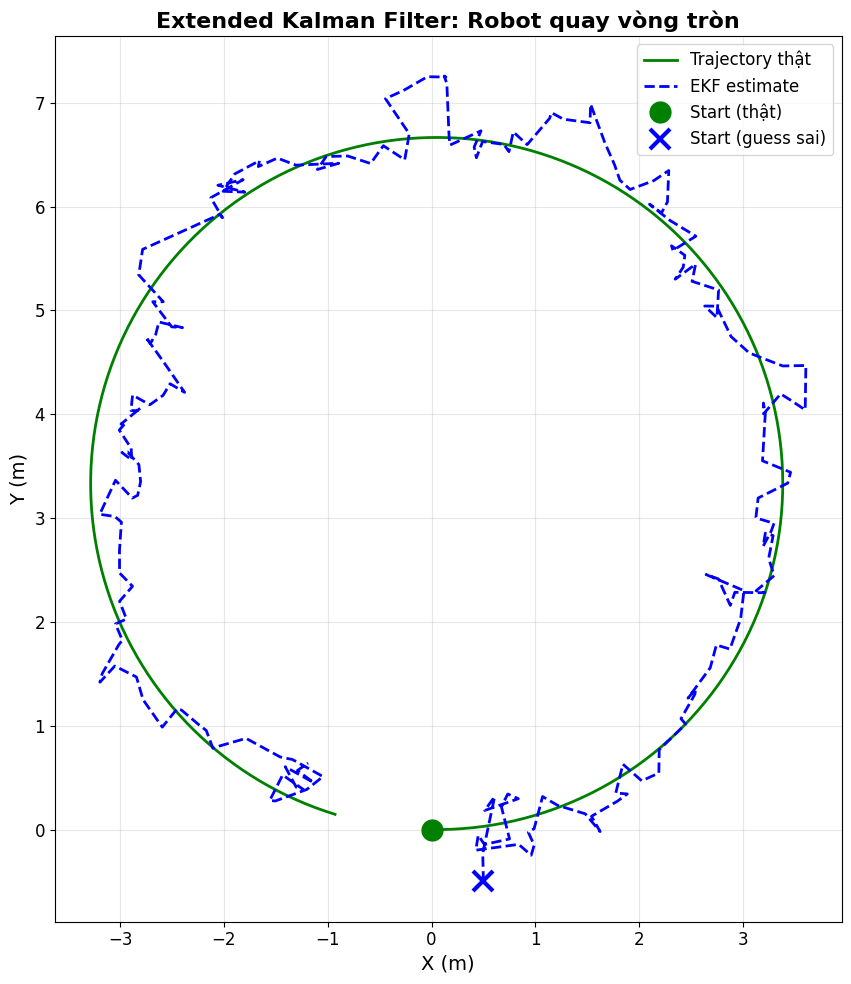

📌 EKF vs KF:
   KF:  x̂ = F·x        (F là hằng số)
   EKF: x̂ = f(x)       (f phi tuyến)
        P̂ = F·P·Fᵀ + Q  (F = Jacobian ∂f/∂x, thay đổi mỗi bước)


In [13]:
def ekf_robot_tracking():
    """EKF cho robot 2D: state = [x, y, theta, v]."""
    np.random.seed(42)
    dt = 0.1
    n_steps = 200
    
    # State: [x, y, θ, v]
    x_true = np.array([0.0, 0.0, 0.0, 1.0])  # Bắt đầu tại gốc, hướng 0°, v=1 m/s
    x_est = np.array([0.5, -0.5, 0.1, 0.8])   # Guess ban đầu (sai!)
    P = np.diag([1, 1, 0.5, 0.5])              # Uncertainty ban đầu
    
    Q = np.diag([0.01, 0.01, 0.01, 0.01])  # Process noise
    R = np.diag([0.5, 0.5])                 # Measurement noise (chỉ đo x, y)
    H = np.array([[1, 0, 0, 0],
                  [0, 1, 0, 0]])            # Đo trực tiếp x, y
    
    omega = 0.3  # Tốc độ quay (rad/s)
    
    true_traj = [x_true[:2].copy()]
    est_traj = [x_est[:2].copy()]
    
    for k in range(n_steps):
        # === TRUE DYNAMICS (phi tuyến!) ===
        x_true[0] += x_true[3] * np.cos(x_true[2]) * dt
        x_true[1] += x_true[3] * np.sin(x_true[2]) * dt
        x_true[2] += omega * dt
        # v không đổi
        
        # === EKF PREDICT ===
        # Hàm phi tuyến f(x)
        x_pred = x_est.copy()
        x_pred[0] += x_est[3] * np.cos(x_est[2]) * dt
        x_pred[1] += x_est[3] * np.sin(x_est[2]) * dt
        x_pred[2] += omega * dt
        
        # Jacobian F = ∂f/∂x  (LINEARIZATION!)
        F = np.eye(4)
        F[0, 2] = -x_est[3] * np.sin(x_est[2]) * dt  # ∂x/∂θ
        F[0, 3] = np.cos(x_est[2]) * dt                # ∂x/∂v
        F[1, 2] = x_est[3] * np.cos(x_est[2]) * dt     # ∂y/∂θ
        F[1, 3] = np.sin(x_est[2]) * dt                 # ∂y/∂v
        
        P_pred = F @ P @ F.T + Q
        
        # === EKF UPDATE ===
        z = x_true[:2] + np.random.multivariate_normal([0,0], R)  # Measurement
        
        S = H @ P_pred @ H.T + R        # Innovation covariance
        K = P_pred @ H.T @ np.linalg.inv(S)  # Kalman gain
        innovation = z - H @ x_pred     # Innovation
        
        x_est = x_pred + K @ innovation
        P = (np.eye(4) - K @ H) @ P_pred
        
        true_traj.append(x_true[:2].copy())
        est_traj.append(x_est[:2].copy())
    
    return np.array(true_traj), np.array(est_traj)

true_traj, est_traj = ekf_robot_tracking()

fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(true_traj[:, 0], true_traj[:, 1], 'g-', linewidth=2, label='Trajectory thật')
ax.plot(est_traj[:, 0], est_traj[:, 1], 'b--', linewidth=2, label='EKF estimate')
ax.plot(true_traj[0, 0], true_traj[0, 1], 'go', markersize=15, label='Start (thật)')
ax.plot(est_traj[0, 0], est_traj[0, 1], 'bx', markersize=15, markeredgewidth=3, label='Start (guess sai)')
ax.set_xlabel('X (m)', fontsize=14)
ax.set_ylabel('Y (m)', fontsize=14)
ax.set_title('Extended Kalman Filter: Robot quay vòng tròn', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("📌 EKF vs KF:")
print("   KF:  x̂ = F·x        (F là hằng số)")
print("   EKF: x̂ = f(x)       (f phi tuyến)")
print("        P̂ = F·P·Fᵀ + Q  (F = Jacobian ∂f/∂x, thay đổi mỗi bước)")

---
<a id='7'></a>
## 7. Error-State Kalman Filter (ESKF)

### Ý tưởng then chốt

Thay vì lọc **toàn bộ state** (phi tuyến, lớn), ESKF tách thành:

$$x^\star = x \oplus \delta x$$
- **Nominal state x**: tích phân phi tuyến (không lọc, không noise)
- **Error state δx**: nhỏ, gần tuyến tính → dùng KF để ước lượng

**Tại sao tốt hơn EKF?**
1. Error state nhỏ → linearization chính xác hơn
2. Error state gần zero → tránh singularity
3. State trên manifold (rotation) → error state trong vector space

> **Ref:** Solà, *Quaternion kinematics for ESKF*, Sections 4–5 (⭐ tài liệu quan trọng nhất)
> **Ref:** LIMOncello eq. (4)–(9)

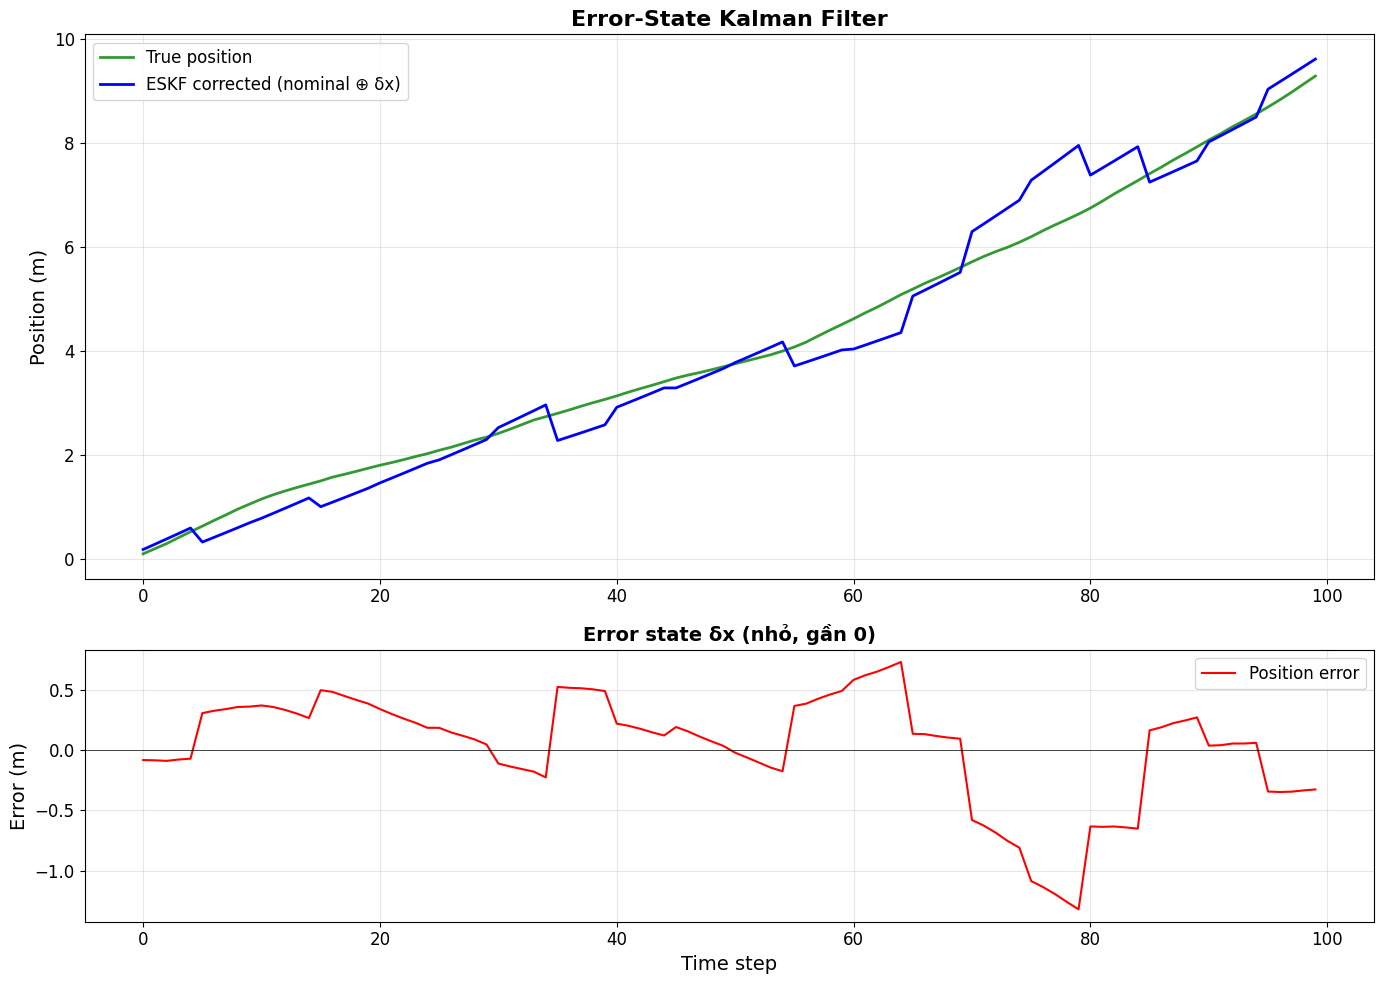

📌 ESKF Flow:
   1. PREDICT: nominal ← nominal ⊞ f(nominal, u, 0)  [phi tuyến, không noise]
              P ← F·P·Fᵀ + Q                         [error covariance]
   2. UPDATE:  δx = K·(z - h(nominal))                [ước lượng error]
   3. INJECT:  nominal ← nominal ⊕ δx                 [sửa nominal]
   4. RESET:   δx ← 0, P ← (I-KH)·P                  [reset error]

📌 Trong LIMOncello paper:
   eq. (4): x⋆ = x ⊕ δx
   eq. (5): x⋆ ← x⋆ ⊞ f(x⋆, u, w)
   eq. (7): F_δx, F_w  (Jacobians cho error state)


In [14]:
def demo_eskf_concept():
    """Minh họa khái niệm ESKF: nominal + error state."""
    np.random.seed(42)
    dt = 0.1
    n_steps = 100
    
    # True dynamics: vị trí 1D với gia tốc
    # x_true = [position, velocity]
    true_states = []
    x_true = np.array([0.0, 1.0])  # pos=0, vel=1 m/s
    accel_true = 0.1  # Gia tốc thật
    
    # === NOMINAL STATE (tích phân không có noise) ===
    x_nominal = np.array([0.0, 1.0])
    
    # === ERROR STATE (nhỏ, lọc bằng KF) ===
    delta_x = np.array([0.0, 0.0])  # Ban đầu = 0
    P = np.diag([0.1, 0.1])         # Uncertainty của error
    
    Q = np.diag([0.01, 0.01])  # Process noise
    R_meas = np.array([[0.5]])  # Measurement noise
    H = np.array([[1.0, 0.0]])  # Đo position
    
    F_err = np.array([[1, dt],
                      [0, 1]])  # Error state dynamics (tuyến tính!)
    
    nominal_traj = []
    corrected_traj = []
    error_traj = []
    
    for k in range(n_steps):
        # True state evolution (với noise)
        process_noise = np.random.multivariate_normal([0,0], Q)
        x_true[0] += x_true[1] * dt
        x_true[1] += accel_true * dt + process_noise[1]
        true_states.append(x_true.copy())
        
        # === ESKF PREDICT ===
        # 1) Nominal: tích phân phi tuyến (không noise)
        x_nominal[0] += x_nominal[1] * dt
        x_nominal[1] += accel_true * dt
        
        # 2) Error: propagate covariance
        P = F_err @ P @ F_err.T + Q
        # (δx vẫn giữ = 0 trong predict, chỉ P thay đổi)
        
        nominal_traj.append(x_nominal.copy())
        
        # === ESKF UPDATE (mỗi 5 bước mới có measurement) ===
        if k % 5 == 0:
            z = x_true[0] + np.random.normal(0, np.sqrt(R_meas[0,0]))
            
            # Innovation: measurement - nominal prediction
            innovation = z - H @ x_nominal
            
            S = H @ P @ H.T + R_meas
            K = P @ H.T @ np.linalg.inv(S)
            
            # Update ERROR state
            delta_x = (K @ innovation).flatten()
            P = (np.eye(2) - K @ H) @ P
            
            # INJECT error vào nominal: x_corrected = nominal ⊕ δx
            x_nominal = x_nominal + delta_x  # (⊕ = + cho ℝⁿ)
            
            # RESET error state về 0
            delta_x = np.array([0.0, 0.0])
        
        corrected_traj.append(x_nominal.copy())
        error_traj.append(delta_x.copy())
    
    return (np.array(true_states), np.array(nominal_traj), 
            np.array(corrected_traj), np.array(error_traj))

true_s, nom_s, corr_s, err_s = demo_eskf_concept()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[2, 1])

axes[0].plot(true_s[:, 0], 'g-', linewidth=2, label='True position', alpha=0.8)
axes[0].plot(corr_s[:, 0], 'b-', linewidth=2, label='ESKF corrected (nominal ⊕ δx)')
axes[0].set_ylabel('Position (m)', fontsize=14)
axes[0].set_title('Error-State Kalman Filter', fontsize=16, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(true_s[:, 0] - corr_s[:, 0], 'r-', linewidth=1.5, label='Position error')
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].set_xlabel('Time step', fontsize=14)
axes[1].set_ylabel('Error (m)', fontsize=14)
axes[1].set_title('Error state δx (nhỏ, gần 0)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📌 ESKF Flow:")
print("   1. PREDICT: nominal ← nominal ⊞ f(nominal, u, 0)  [phi tuyến, không noise]")
print("              P ← F·P·Fᵀ + Q                         [error covariance]")
print("   2. UPDATE:  δx = K·(z - h(nominal))                [ước lượng error]")
print("   3. INJECT:  nominal ← nominal ⊕ δx                 [sửa nominal]")
print("   4. RESET:   δx ← 0, P ← (I-KH)·P                  [reset error]")
print()
print("📌 Trong LIMOncello paper:")
print("   eq. (4): x⋆ = x ⊕ δx")
print("   eq. (5): x⋆ ← x⋆ ⊞ f(x⋆, u, w)")
print("   eq. (7): F_δx, F_w  (Jacobians cho error state)")

---
<a id='8'></a>
## 8. Iterated Error-State Kalman Filter (IESKF)

### IESKF = ESKF + Iteration

Vấn đề với ESKF/EKF: linearization tại một điểm sai → kết quả sai.

**Giải pháp IESKF:** Lặp update step nhiều lần, mỗi lần re-linearize tại estimate mới, cho đến khi hội tụ.

$$\hat{x}_{j+1} = \hat{x}_j \oplus \left(-K_j z_j - (I - K_j H_j) J_j^{-1} (\hat{x}_j \ominus \hat{x})\right)$$

Hội tụ khi: $\|\hat{x}_{j+1} \ominus \hat{x}_j\| < \varepsilon$

> **Ref:** LIMOncello eq. (20a), (20b)
> **Ref:** IKFoM paper (He, Xu, Zhang), arXiv:2102.03804

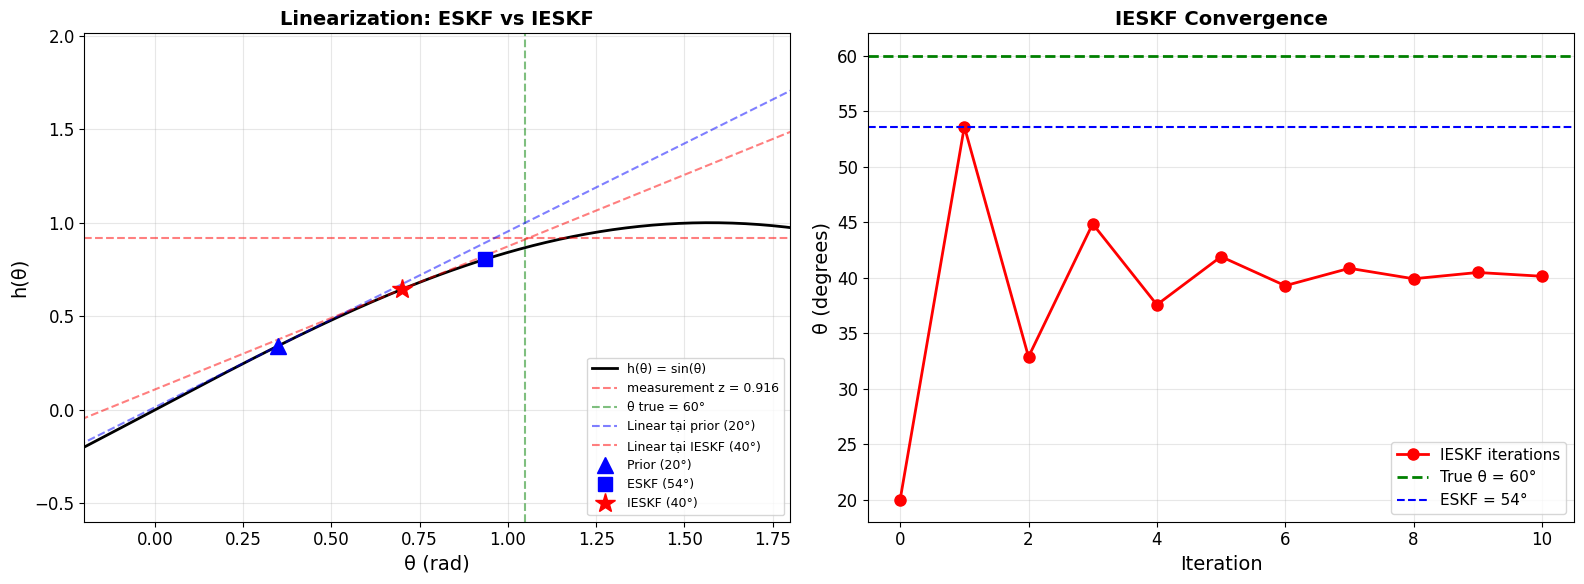

True θ:    60.00°
Prior:     20.00°
ESKF:      53.59° (1 iteration, linearize tại prior)
IESKF:     40.11° (10 iterations)

📌 IESKF gần true hơn vì re-linearize nhiều lần!
   Đây chính là eq. (20b) trong LIMOncello paper.


In [15]:
def demo_ieskf_vs_eskf():
    """So sánh ESKF (1 iteration) vs IESKF (nhiều iterations).
    
    Bài toán: ước lượng góc θ từ measurement phi tuyến h(θ) = sin(θ).
    """
    np.random.seed(42)
    
    # True state
    theta_true = np.radians(60)  # 60 degrees
    
    # Measurement: h(θ) = sin(θ)  (phi tuyến!)
    R_meas = 0.01  # Measurement noise variance
    z = np.sin(theta_true) + np.random.normal(0, np.sqrt(R_meas))
    
    # Prior
    theta_prior = np.radians(20)  # Guess ban đầu (sai khá nhiều!)
    P_prior = np.radians(30)**2   # Uncertainty lớn
    
    # === ESKF: 1 iteration ===
    H_eskf = np.cos(theta_prior)  # Jacobian ∂h/∂θ = cos(θ), tại prior
    innovation = z - np.sin(theta_prior)
    S = H_eskf * P_prior * H_eskf + R_meas
    K = P_prior * H_eskf / S
    theta_eskf = theta_prior + K * innovation
    
    # === IESKF: nhiều iterations ===
    theta_j = theta_prior
    max_iters = 10
    ieskf_history = [theta_prior]
    
    for j in range(max_iters):
        # Re-linearize tại θ_j (không phải tại prior!)
        H_j = np.cos(theta_j)
        z_j = z - np.sin(theta_j)  # Residual tại θ_j
        
        # Projected prior covariance
        # (đơn giản hóa cho scalar case)
        S_j = H_j * P_prior * H_j + R_meas
        K_j = P_prior * H_j / S_j
        
        # Update với prior constraint
        theta_new = theta_j + K_j * z_j - K_j * H_j * (theta_j - theta_prior)
        
        # Kiểm tra hội tụ
        if abs(theta_new - theta_j) < 1e-6:
            theta_j = theta_new
            ieskf_history.append(theta_j)
            break
        theta_j = theta_new
        ieskf_history.append(theta_j)
    
    # Trực quan hóa
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: hàm h(θ) = sin(θ) và linearization
    theta_range = np.linspace(-0.5, 2, 200)
    ax1.plot(theta_range, np.sin(theta_range), 'k-', linewidth=2, label='h(θ) = sin(θ)')
    ax1.axhline(y=z, color='red', linestyle='--', alpha=0.5, label=f'measurement z = {z:.3f}')
    ax1.axvline(x=theta_true, color='green', linestyle='--', alpha=0.5, label=f'θ true = {np.degrees(theta_true):.0f}°')
    
    # Linearization tại prior (ESKF)
    lin_eskf = np.sin(theta_prior) + np.cos(theta_prior) * (theta_range - theta_prior)
    ax1.plot(theta_range, lin_eskf, 'b--', alpha=0.5, label=f'Linear tại prior ({np.degrees(theta_prior):.0f}°)')
    
    # Linearization tại IESKF final (re-linearized)
    lin_ieskf = np.sin(theta_j) + np.cos(theta_j) * (theta_range - theta_j)
    ax1.plot(theta_range, lin_ieskf, 'r--', alpha=0.5, label=f'Linear tại IESKF ({np.degrees(theta_j):.0f}°)')
    
    ax1.plot(theta_prior, np.sin(theta_prior), 'b^', markersize=12, label=f'Prior ({np.degrees(theta_prior):.0f}°)')
    ax1.plot(theta_eskf, np.sin(theta_eskf), 'bs', markersize=10, label=f'ESKF ({np.degrees(theta_eskf):.0f}°)')
    ax1.plot(theta_j, np.sin(theta_j), 'r*', markersize=15, label=f'IESKF ({np.degrees(theta_j):.0f}°)')
    
    ax1.set_xlabel('θ (rad)', fontsize=14)
    ax1.set_ylabel('h(θ)', fontsize=14)
    ax1.set_title('Linearization: ESKF vs IESKF', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=9, loc='lower right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(-0.2, 1.8)
    
    # Plot 2: IESKF convergence
    ax2.plot(range(len(ieskf_history)), np.degrees(ieskf_history), 'ro-', linewidth=2, markersize=8, label='IESKF iterations')
    ax2.axhline(y=np.degrees(theta_true), color='green', linestyle='--', linewidth=2, label=f'True θ = {np.degrees(theta_true):.0f}°')
    ax2.axhline(y=np.degrees(theta_eskf), color='blue', linestyle='--', linewidth=1.5, label=f'ESKF = {np.degrees(theta_eskf):.0f}°')
    ax2.set_xlabel('Iteration', fontsize=14)
    ax2.set_ylabel('θ (degrees)', fontsize=14)
    ax2.set_title('IESKF Convergence', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"True θ:    {np.degrees(theta_true):.2f}°")
    print(f"Prior:     {np.degrees(theta_prior):.2f}°")
    print(f"ESKF:      {np.degrees(theta_eskf):.2f}° (1 iteration, linearize tại prior)")
    print(f"IESKF:     {np.degrees(theta_j):.2f}° ({len(ieskf_history)-1} iterations)")
    print(f"\n📌 IESKF gần true hơn vì re-linearize nhiều lần!")
    print(f"   Đây chính là eq. (20b) trong LIMOncello paper.")

demo_ieskf_vs_eskf()

---
<a id='9'></a>
## 9. Tổng hợp: Ánh xạ kiến thức → Paper LIMOncello

Bây giờ bạn đã có nền tảng để đọc paper. Đây là bản đồ ánh xạ:

| Công thức trong paper | Kiến thức cần | Section trong notebook |
|---|---|---|
| eq. (1): ⊕, ⊖ operators | Lie group, Exp/Log | Section 3, 4.1 |
| eq. (4): x⋆ = x ⊕ δx | ESKF concept | Section 7 |
| eq. (7): F_δx, F_w Jacobians | Jacobian, chain rule, ESKF | Section 6, 7 |
| eq. (10): Γ ∈ SGal(3) | Lie groups, ma trận 5×5 | Section 4.3 |
| eq. (12): IMU propagation | SGal(3), ⊕ operator | Section 4.4 |
| eq. (13): state vector x ∈ M | Bundle manifold | Section 4.2, 4.3 |
| eq. (15): prediction | ESKF predict step | Section 7 |
| eq. (17): measurement h_i(x) | Point-to-plane, SE(3) transform | Section 4.2 |
| eq. (18): Jacobians ∂h/∂Γ | Jacobian, skew matrix | Section 2.2, 6 |
| eq. (20): MAP update | IESKF iteration | Section 8 |

### Thứ tự đọc paper đề xuất

1. **Section I**: đọc bình thường
2. **Section II.A**: ôn lại Section 3 (Exp/Log) và Section 4.1 (⊕/⊖)
3. **Section II.C**: ôn lại Section 4.3 (SGal(3))
4. **Section II.B**: ôn lại Section 7 (ESKF) và Section 8 (IESKF)
5. **Section III**: áp dụng tất cả — đây là core của hệ thống
6. **Section IV–V**: kết quả thực nghiệm, không cần toán

### Tài liệu đọc thêm (sắp theo thứ tự ưu tiên)

| # | Tài liệu | Link | Ghi chú |
|---|---|---|---|
| 1 | Solà — "Quaternion kinematics for ESKF" | [arXiv:1711.02508](https://arxiv.org/abs/1711.02508) | ⭐ Cùng tác giả, ESKF chi tiết nhất |
| 2 | Solà et al. — "A micro Lie theory" | [arXiv:1812.01537](https://arxiv.org/abs/1812.01537) | ⭐ Cùng tác giả, Lie groups cho robotics |
| 3 | Kelly — "All about SGal(3)" | [arXiv:2312.07555](https://arxiv.org/abs/2312.07555) | SGal(3) chi tiết |
| 4 | Barfoot — "State Estimation for Robotics" 2nd Ed. | [PDF](https://asrl.utias.utoronto.ca/~tdb/bib/barfoot_ser24.pdf) | Sách kinh điển, miễn phí |
| 5 | Roger Labbe — "Kalman Filters in Python" | [GitHub](https://github.com/rlabbe/Kalman-and-Bayesian-Filters-in-Python) | Interactive Jupyter Book |
| 6 | 3Blue1Brown — Essence of Linear Algebra | [YouTube](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) | Trực quan |
| 7 | kalmanfilter.net | [Website](https://kalmanfilter.net/) | KF qua ví dụ số |

---
*Cập nhật: Tháng 4/2026*